<a href="https://colab.research.google.com/github/pylayaswanthteja/ML_Lab/blob/main/Lab02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity


In [4]:
from google.colab import drive
drive.mount('/content/drive')

DATA_FILE = "/content/drive/MyDrive/ML_lab/Lab Session Data.xlsx"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ---------------------------------------------------------
# Read Excel Sheet
# ---------------------------------------------------------
def load_sheet(file_name, sheet_name):

    dataframe = pd.read_excel(file_name, sheet_name=sheet_name)

    return dataframe


# ---------------------------------------------------------
# Prepare Feature Matrix (X) and Output Vector (y)
# ---------------------------------------------------------
def prepare_feature_output_matrix(dataframe):

    feature_matrix = dataframe[
        ["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]
    ].to_numpy()

    output_vector = dataframe["Payment (Rs)"].to_numpy()

    return feature_matrix, output_vector


# ---------------------------------------------------------
# Vector Space Dimension
# ---------------------------------------------------------
def calculate_vector_dimension(feature_matrix):

    return feature_matrix.shape[1]


# ---------------------------------------------------------
# Number of Observation Vectors
# ---------------------------------------------------------
def calculate_number_of_vectors(feature_matrix):

    return feature_matrix.shape[0]


# ---------------------------------------------------------
# Matrix Rank
# ---------------------------------------------------------
def calculate_matrix_rank(feature_matrix):

    return np.linalg.matrix_rank(feature_matrix)


# ---------------------------------------------------------
# Product Cost using Pseudo Inverse
# ---------------------------------------------------------
def calculate_product_cost(feature_matrix, output_vector):

    pseudo_inverse = np.linalg.pinv(feature_matrix)

    product_cost = np.dot(pseudo_inverse, output_vector)

    return product_cost

In [7]:
# ---------------------------------------------------------
# Create Customer Class Labels
# ---------------------------------------------------------
def assign_customer_category(payment):

    if payment > 200:
        return "RICH"
    else:
        return "POOR"


# ---------------------------------------------------------
# Add Customer Category Column
# ---------------------------------------------------------
def classify_customers(dataframe):

    customer_data = dataframe.copy()

    customer_data["Customer Category"] = customer_data["Payment (Rs)"].apply(assign_customer_category)

    return customer_data


# ---------------------------------------------------------
# Prepare Features and Labels for Classification
# ---------------------------------------------------------
def prepare_classifier_data(dataframe):

    feature_matrix = dataframe[
        ["Candies (#)", "Mangoes (Kg)", "Milk Packets (#)"]
    ].to_numpy()

    target_vector = dataframe["Customer Category"].to_numpy()

    return feature_matrix, target_vector


# ---------------------------------------------------------
# Train Decision Tree Classifier
# ---------------------------------------------------------
def build_classifier(feature_matrix, target_vector):

    classifier = DecisionTreeClassifier(random_state=42)

    classifier.fit(feature_matrix, target_vector)

    return classifier


# ---------------------------------------------------------
# Predict Customer Category
# ---------------------------------------------------------
def predict_customer_class(classifier, feature_matrix):

    predicted_class = classifier.predict(feature_matrix)

    return predicted_class

In [10]:
# ---------------------------------------------------------
# Read IRCTC Stock Data
# ---------------------------------------------------------
def load_stock_data():

    stock_dataframe = load_sheet(DATA_FILE, "IRCTC Stock Price")

    return stock_dataframe


# ---------------------------------------------------------
# Mean using NumPy
# ---------------------------------------------------------
def package_mean(price_data):

    return np.mean(price_data)


# ---------------------------------------------------------
# Variance using NumPy
# ---------------------------------------------------------
def package_variance(price_data):

    return np.var(price_data)


# ---------------------------------------------------------
# Mean without NumPy
# ---------------------------------------------------------
def custom_mean(price_data):

    total = 0

    count = 0

    for value in price_data:

        total += value

        count += 1

    return total / count


# ---------------------------------------------------------
# Variance without NumPy
# ---------------------------------------------------------
def custom_variance(price_data):

    mean_value = custom_mean(price_data)

    variance_sum = 0

    count = 0

    for value in price_data:

        variance_sum += (value - mean_value) ** 2

        count += 1

    return variance_sum / count


# ---------------------------------------------------------
# Average Execution Time
# ---------------------------------------------------------
def calculate_execution_time(function_name, data):

    execution_times = []

    for i in range(10):

        start_time = time.time()

        function_name(data)

        end_time = time.time()

        execution_times.append(end_time - start_time)

    return np.mean(execution_times)


# ---------------------------------------------------------
# Wednesday Sample Mean
# ---------------------------------------------------------
def wednesday_mean(stock_dataframe):

    wednesday_price = stock_dataframe[
        stock_dataframe["Day"] == "Wed"
    ]["Price"].values

    return np.mean(wednesday_price)


# ---------------------------------------------------------
# April Sample Mean
# ---------------------------------------------------------
def april_mean(stock_dataframe):

    april_price = stock_dataframe[
        stock_dataframe["Month"] == "Apr"
    ]["Price"].values

    return np.mean(april_price)


# ---------------------------------------------------------
# Probability of Loss
# ---------------------------------------------------------
def probability_of_loss(stock_dataframe):

    loss_days = stock_dataframe["Chg%"].apply(lambda value: value < 0)

    return loss_days.sum() / len(stock_dataframe)


# ---------------------------------------------------------
# Probability of Profit on Wednesday
# ---------------------------------------------------------
def probability_profit_on_wednesday(stock_dataframe):

    wednesday_data = stock_dataframe[
        stock_dataframe["Day"] == "Wed"
    ]

    profit = wednesday_data["Chg%"] > 0

    return profit.sum() / len(stock_dataframe)


# ---------------------------------------------------------
# Conditional Probability
# ---------------------------------------------------------
def conditional_probability(stock_dataframe):

    wednesday_data = stock_dataframe[
        stock_dataframe["Day"] == "Wed"
    ]

    profit_days = wednesday_data["Chg%"] > 0

    return profit_days.sum() / len(wednesday_data)


# ---------------------------------------------------------
# Scatter Plot
# ---------------------------------------------------------
def draw_scatter_plot(stock_dataframe):

    plt.figure(figsize=(8,5))

    plt.scatter(stock_dataframe["Day"],
                stock_dataframe["Chg%"])

    plt.title("Chg% vs Day")

    plt.xlabel("Day")

    plt.ylabel("Chg %")

    plt.grid(True)

    plt.show()

In [13]:
# ---------------------------------------------------------
# Load Thyroid Dataset
# ---------------------------------------------------------
def load_thyroid_data():

    thyroid_dataframe = load_sheet(DATA_FILE, "thyroid0387_UCI")

    return thyroid_dataframe


# ---------------------------------------------------------
# Find Data Types
# ---------------------------------------------------------
def get_attribute_datatypes(dataframe):

    return dataframe.dtypes


# ---------------------------------------------------------
# Find Encoding Type
# ---------------------------------------------------------
def identify_encoding(dataframe):

    encoding = {}

    for column in dataframe.columns:

        if dataframe[column].dtype == "object":

            unique_values = dataframe[column].nunique()

            if unique_values == 2:

                encoding[column] = "Label Encoding"

            else:

                encoding[column] = "One-Hot Encoding"

        else:

            encoding[column] = "Not Required"

    return encoding


# ---------------------------------------------------------
# Numeric Column Range
# ---------------------------------------------------------
def numeric_range(dataframe):

    numeric_columns = dataframe.select_dtypes(include=[np.number])

    return numeric_columns.min(), numeric_columns.max()


# ---------------------------------------------------------
# Missing Values
# ---------------------------------------------------------
def missing_values(dataframe):

    return dataframe.isnull().sum()


# ---------------------------------------------------------
# Outlier Count using IQR
# ---------------------------------------------------------
def detect_outliers(dataframe):

    outlier_result = {}

    numeric_columns = dataframe.select_dtypes(include=[np.number])

    for column in numeric_columns.columns:

        Q1 = numeric_columns[column].quantile(0.25)

        Q3 = numeric_columns[column].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR

        upper = Q3 + 1.5 * IQR

        count = ((numeric_columns[column] < lower) |
                 (numeric_columns[column] > upper)).sum()

        outlier_result[column] = count

    return outlier_result


# ---------------------------------------------------------
# Mean and Standard Deviation
# ---------------------------------------------------------
def numeric_statistics(dataframe):

    numeric_columns = dataframe.select_dtypes(include=[np.number])

    mean_values = numeric_columns.mean()

    variance_values = numeric_columns.var()

    standard_deviation = numeric_columns.std()

    return mean_values, variance_values, standard_deviation

A1 : PURCHASE DATA ANALYSIS

Dimension of Vector Space : 3
Number of Observation Vectors : 10
Rank of Feature Matrix : 3

Estimated Product Cost
Candies        : Rs. 1.00
Mangoes        : Rs. 55.00
Milk Packets   : Rs. 18.00


A2 : CUSTOMER CLASSIFICATION
  Customer  Candies (#)  Mangoes (Kg)  Milk Packets (#)  Payment (Rs)  \
0      C_1           20             6                 2           386   
1      C_2           16             3                 6           289   
2      C_3           27             6                 2           393   
3      C_4           19             1                 2           110   
4      C_5           24             4                 2           280   
5      C_6           22             1                 5           167   
6      C_7           15             4                 2           271   
7      C_8           18             4                 2           274   
8      C_9           21             1                 4           148   
9     C_10    

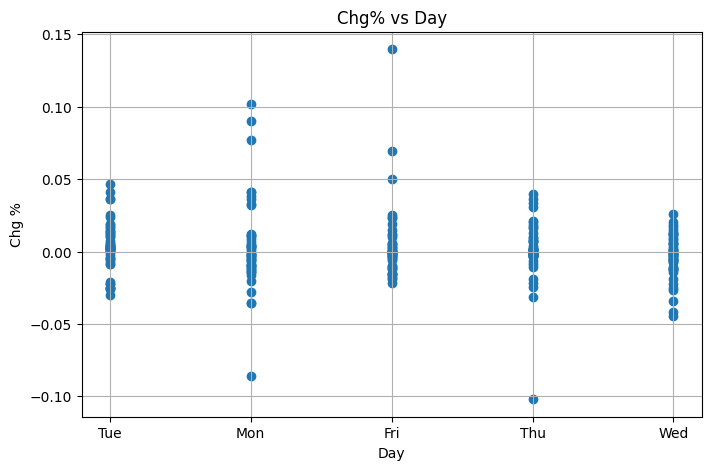



A4 : THYROID DATA EXPLORATION

Data Types
Record ID                     int64
age                           int64
sex                          object
on thyroxine                 object
query on thyroxine           object
on antithyroid medication    object
sick                         object
pregnant                     object
thyroid surgery              object
I131 treatment               object
query hypothyroid            object
query hyperthyroid           object
lithium                      object
goitre                       object
tumor                        object
hypopituitary                object
psych                        object
TSH measured                 object
TSH                          object
T3 measured                  object
T3                           object
TT4 measured                 object
TT4                          object
T4U measured                 object
T4U                          object
FTI measured                 object
FTI                 

In [14]:
def main():

    # Read Purchase Data
    purchase_data = load_sheet(DATA_FILE, "Purchase data")

    # Feature Matrix and Output Vector
    feature_matrix, output_vector = prepare_feature_output_matrix(purchase_data)

    # Matrix Details
    vector_dimension = calculate_vector_dimension(feature_matrix)

    total_vectors = calculate_number_of_vectors(feature_matrix)

    feature_rank = calculate_matrix_rank(feature_matrix)

    # Product Cost
    estimated_cost = calculate_product_cost(feature_matrix, output_vector)

    # Display Output
    print("=" * 60)
    print("A1 : PURCHASE DATA ANALYSIS")
    print("=" * 60)

    print("\nDimension of Vector Space :", vector_dimension)

    print("Number of Observation Vectors :", total_vectors)

    print("Rank of Feature Matrix :", feature_rank)

    print("\nEstimated Product Cost")

    print(f"Candies        : Rs. {estimated_cost[0]:.2f}")

    print(f"Mangoes        : Rs. {estimated_cost[1]:.2f}")

    print(f"Milk Packets   : Rs. {estimated_cost[2]:.2f}")

    # =====================================================
    # A2 : Customer Classification
    # =====================================================

    classified_data = classify_customers(purchase_data)

    X, y = prepare_classifier_data(classified_data)

    classifier_model = build_classifier(X, y)

    predicted_output = predict_customer_class(classifier_model, X)

    classified_data["Predicted Category"] = predicted_output

    print("\n")
    print("=" * 60)
    print("A2 : CUSTOMER CLASSIFICATION")
    print("=" * 60)

    print(classified_data)

    print("\nTotal Customers :", len(classified_data))

    print("RICH Customers :",
          (classified_data["Customer Category"] == "RICH").sum())

    print("POOR Customers :",
          (classified_data["Customer Category"] == "POOR").sum())
        # =====================================================
    # A3 : IRCTC STOCK ANALYSIS
    # =====================================================

    stock_data = load_stock_data()

    price = stock_data["Price"].values

    population_mean = package_mean(price)

    population_variance = package_variance(price)

    own_mean = custom_mean(price)

    own_variance = custom_variance(price)

    numpy_time = calculate_execution_time(package_mean, price)

    custom_time = calculate_execution_time(custom_mean, price)

    wed_mean = wednesday_mean(stock_data)

    apr_mean = april_mean(stock_data)

    loss_probability = probability_of_loss(stock_data)

    profit_wednesday = probability_profit_on_wednesday(stock_data)

    conditional_profit = conditional_probability(stock_data)

    print("\n")
    print("="*60)
    print("A3 : IRCTC STOCK DATA ANALYSIS")
    print("="*60)

    print("\nPopulation Mean :", population_mean)

    print("Population Variance :", population_variance)

    print("\nCustom Mean :", own_mean)

    print("Custom Variance :", own_variance)

    print("\nAverage Time using NumPy :", numpy_time)

    print("Average Time using Custom Function :", custom_time)

    print("\nWednesday Sample Mean :", wed_mean)

    print("April Sample Mean :", apr_mean)

    print("\nProbability of Loss :", loss_probability)

    print("Probability of Profit on Wednesday :", profit_wednesday)

    print("Conditional Probability of Profit given Wednesday :", conditional_profit)

    draw_scatter_plot(stock_data)
        # =====================================================
    # A4 : THYROID DATA EXPLORATION
    # =====================================================

    thyroid_data = load_thyroid_data()

    datatypes = get_attribute_datatypes(thyroid_data)

    encoding = identify_encoding(thyroid_data)

    minimum, maximum = numeric_range(thyroid_data)

    missing = missing_values(thyroid_data)

    outliers = detect_outliers(thyroid_data)

    mean, variance, std = numeric_statistics(thyroid_data)

    print("\n")
    print("=" * 60)
    print("A4 : THYROID DATA EXPLORATION")
    print("=" * 60)

    print("\nData Types")
    print(datatypes)

    print("\nSuggested Encoding")
    for key, value in encoding.items():
        print(f"{key} : {value}")

    print("\nMinimum Values")
    print(minimum)

    print("\nMaximum Values")
    print(maximum)

    print("\nMissing Values")
    print(missing)

    print("\nOutlier Count")
    for key, value in outliers.items():
        print(f"{key} : {value}")

    print("\nMean")
    print(mean)

    print("\nVariance")
    print(variance)

    print("\nStandard Deviation")
    print(std)


if __name__ == "__main__":
    main()